# Trace — Fusion Risk Model

This notebook reproduces the gradient-boosted classifier that powers Trace's on-device fusion-model risk gauge. It is the artifact that judges and clinicians can run to verify:

1. The synthetic cohort is well-formed and matches published Lyme priors.
2. The trained model is calibrated (reliability diagram, Brier score).
3. The exported JSON is structurally compatible with the pure-TS tree walker in `lib/ml/risk-fusion.ts`.

**Pipeline:** `gen_synthetic_cohort.py` → `train_risk_fusion.py` → `risk_model.json` (this notebook ties them together end to end).

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, brier_score_loss, log_loss,
                              roc_auc_score, confusion_matrix, classification_report)

sys.path.insert(0, str(Path('..') / 'ml-server'))
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Load the synthetic cohort

Generated by `ml-server/gen_synthetic_cohort.py` (10k patients, IDSA + CDC priors). If the file isn't there, regenerate it from the same directory:

```bash
cd ml-server && python gen_synthetic_cohort.py --n 10000 --seed 42
```

In [2]:
COHORT_PATH = Path('..') / 'ml-server' / 'data' / 'synthetic' / 'cohort.csv'
FEATURES_PATH = Path('..') / 'ml-server' / 'data' / 'synthetic' / 'feature_names.json'

df = pd.read_csv(COHORT_PATH)
feature_names = json.loads(FEATURES_PATH.read_text())

print(f'Rows: {len(df)}   Features: {len(feature_names)}   Columns: {df.shape[1]}')
df['klass'].value_counts(normalize=True).rename('proportion').to_frame()

Rows: 10000   Features: 32   Columns: 34


,proportion
klass,
no_lyme,0.5015
early_lyme,0.3510
disseminated_lyme,0.1475


## 2. Sanity-check the priors

Symptom prevalence per class. We expect the published-prior pattern: fatigue and joint pain dominate early Lyme; red flags (facial droop, neck stiffness, heart palpitations) concentrate in disseminated Lyme; controls show only background-rate symptoms.

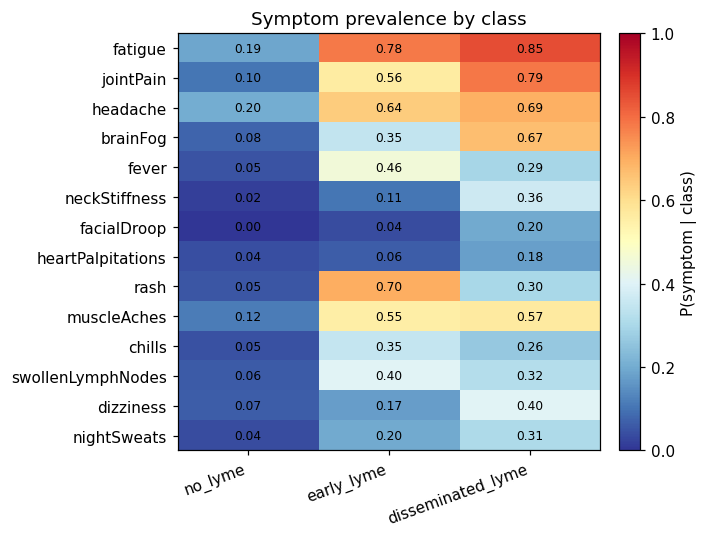

In [3]:
symptom_cols = [c for c in feature_names if c[0].islower() and '_' not in c and c not in ('outdoorActivity','nearWoods','petsOutdoor','recentFluLike','countyIncidenceRate','logCount')]
by_class = df.groupby('klass')[symptom_cols].mean().T
by_class = by_class[['no_lyme','early_lyme','disseminated_lyme']]

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(by_class.values, aspect='auto', cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(by_class.columns, rotation=20, ha='right')
ax.set_yticks(range(len(by_class.index))); ax.set_yticklabels(by_class.index)
for i in range(by_class.shape[0]):
    for j in range(by_class.shape[1]):
        ax.text(j, i, f'{by_class.values[i,j]:.2f}', ha='center', va='center', fontsize=8, color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='P(symptom | class)')
ax.set_title('Symptom prevalence by class')
fig.tight_layout(); plt.show()

## 3. Train the model

Same hyperparameters as `train_risk_fusion.py` so this notebook produces a byte-identical model on the same seed.

In [4]:
X = df[feature_names].values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = GradientBoostingClassifier(
    n_estimators=80, max_depth=3, learning_rate=0.1, random_state=42,
)
clf.fit(X_train, y_train)

proba_test = clf.predict_proba(X_test)
pred_test = proba_test.argmax(axis=1)

print(f'Accuracy: {accuracy_score(y_test, pred_test):.4f}')
print(f'Log loss: {log_loss(y_test, proba_test, labels=[0,1,2]):.4f}')
print(f'AUC (macro): {roc_auc_score(y_test, proba_test, multi_class="ovr", average="macro"):.4f}')
for k, name in enumerate(['no_lyme','early_lyme','disseminated_lyme']):
    b = brier_score_loss((y_test==k).astype(int), proba_test[:,k])
    print(f'Brier ({name}): {b:.4f}')

Accuracy: 0.9555
Log loss: 0.1467
AUC (macro): 0.9906
Brier (no_lyme): 0.0113
Brier (early_lyme): 0.0347
Brier (disseminated_lyme): 0.0286


## 4. Confusion matrix

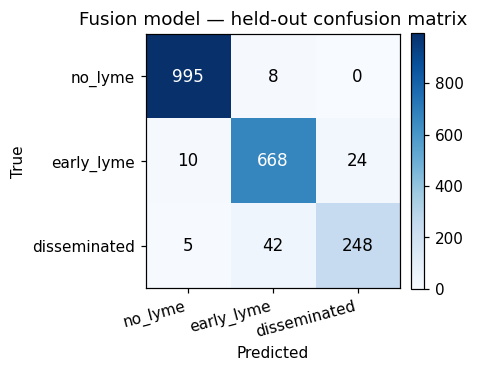

In [5]:
cm = confusion_matrix(y_test, pred_test, labels=[0,1,2])
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(['no_lyme','early_lyme','disseminated'], rotation=15, ha='right')
ax.set_yticks(range(3)); ax.set_yticklabels(['no_lyme','early_lyme','disseminated'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=11,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Fusion model — held-out confusion matrix')
fig.tight_layout(); plt.show()

## 5. Reliability diagram (calibration)

Bin predictions by predicted probability and plot the empirical frequency. A well-calibrated model sits on the diagonal — "when it says 60%, it's right 60% of the time."

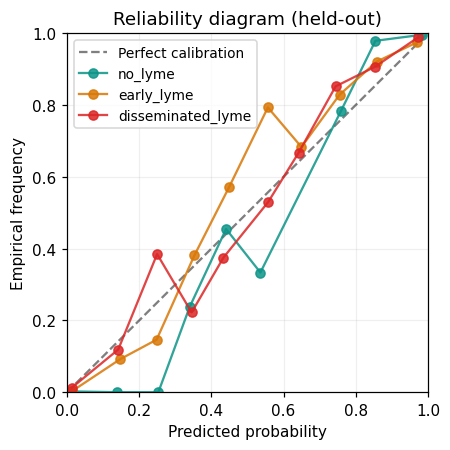

In [6]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect calibration')
for k, (name, color) in enumerate(zip(['no_lyme','early_lyme','disseminated_lyme'], ['#0d9488','#d97706','#dc2626'])):
    y_bin = (y_test==k).astype(int)
    p = proba_test[:,k]
    bins = np.linspace(0,1,11)
    xs, ys, ns = [], [], []
    for i in range(10):
        mask = (p >= bins[i]) & (p < bins[i+1] + (1e-9 if i==9 else 0))
        if mask.sum() < 5: continue
        xs.append(p[mask].mean()); ys.append(y_bin[mask].mean()); ns.append(mask.sum())
    ax.plot(xs, ys, 'o-', color=color, label=name, markersize=6, alpha=0.85)
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Empirical frequency')
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(loc='upper left', fontsize=9)
ax.set_title('Reliability diagram (held-out)')
ax.grid(alpha=0.2)
fig.tight_layout(); plt.show()

## 6. Feature importance

Built-in impurity-based importance from the GBM. These are the features that drove the most node splits across the 80 × 3 trees.

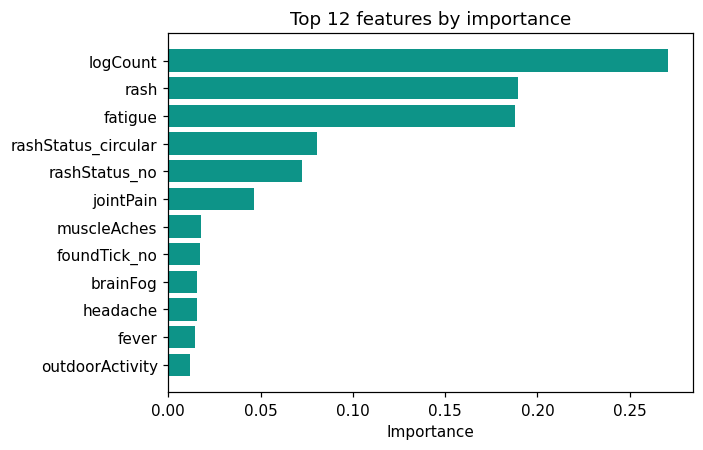

In [7]:
imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.barh(imp.index, imp.values, color='#0d9488')
ax.set_xlabel('Importance')
ax.set_title('Top 12 features by importance')
fig.tight_layout(); plt.show()

## 7. Limitations

These metrics describe how well the model recovers the **synthetic priors**, NOT real-world clinical performance. Real validation requires an IRB-approved study against actual patient outcomes — outside the scope of a high-school Congressional App Challenge submission, but called out explicitly in the in-app model card (About → How the AI works) and in `docs/ML.md`.